# BusinessNewsDaily 批量抓取与可视化流水线

本 Notebook 将从 `input_urls.txt` 读取 URL 列表，完成：
- URL 清洗与可访问性预检查
- 并发抓取 HTML（重试/限速/超时）
- 正文与元数据抽取
- 质量评估与异常样本分析
- 结构化导出与增量爬取机制

In [2]:
# 依赖导入与全局配置
import asyncio
import hashlib
import json
import random
import re
import time
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)

BASE_DIR = Path.cwd()
INPUT_FILE = BASE_DIR / 'input_urls.txt'
OUTPUT_DIR = BASE_DIR / 'dataset_businessnewsdaily'
RAW_DIR = OUTPUT_DIR / 'raw'
CLEAN_DIR = OUTPUT_DIR / 'clean'
REPORT_DIR = OUTPUT_DIR / 'reports'
for d in [OUTPUT_DIR, RAW_DIR, CLEAN_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONCURRENCY = 12
REQUEST_TIMEOUT = 20
MAX_RETRIES = 3
BASE_DELAY = 0.2
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('BASE_DIR =', BASE_DIR)
print('INPUT_FILE exists =', INPUT_FILE.exists())

BASE_DIR = e:\研究生资料\7102\project\data
INPUT_FILE exists = True


## 1) 读取 `input_urls.txt` 并预览样本

Raw URL count: 1494


,url_raw,path_type
0,https://www.businessnewsdaily.com/1306-friends-work-leads-to-longer-life.html,Numeric article path
1,https://www.businessnewsdaily.com/15224-salesforce-social-media-integration.html,Numeric article path
2,https://www.businessnewsdaily.com/10243-online-legal-services-pros-cons.html,Numeric article path
3,https://www.businessnewsdaily.com/4173-personality-traits-successful-sales-people.html,Numeric article path
4,https://www.businessnewsdaily.com/4308-reit.html,Numeric article path


,url_raw,path_type
1489,https://www.businessnewsdaily.com/4427-cloud-computing-small-business.html,Numeric article path
1490,https://www.businessnewsdaily.com/5783-compare-small-business-insurance-quotes.html,Numeric article path
1491,https://www.businessnewsdaily.com/9024-biggest-business-insurance-risks.html,Numeric article path
1492,https://www.businessnewsdaily.com/8595-food-truck-tips.html,Numeric article path
1493,https://www.businessnewsdaily.com/2747-great-business-ideas.html,Numeric article path


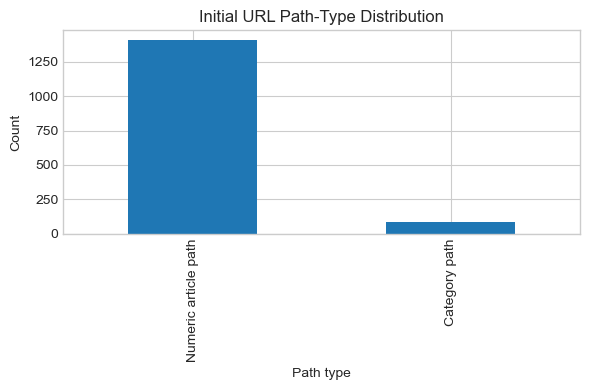

In [3]:
# Load URLs and visualize basic path distribution
lines = INPUT_FILE.read_text(encoding='utf-8', errors='ignore').splitlines()
urls_raw = [x.strip() for x in lines if x.strip()]
df_urls = pd.DataFrame({'url_raw': urls_raw})

# Detect path type: numeric article path vs category path
id_pattern = re.compile(r'^https?://www\.businessnewsdaily\.com/\d+-.+')
def path_type(u: str) -> str:
    return 'Numeric article path' if id_pattern.match(u) else 'Category path'

df_urls['path_type'] = df_urls['url_raw'].map(path_type)

print('Raw URL count:', len(df_urls))
display(df_urls.head(5))
display(df_urls.tail(5))

ax = df_urls['path_type'].value_counts().plot(kind='bar', figsize=(6, 4), title='Initial URL Path-Type Distribution')
ax.set_xlabel('Path type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 2) URL 清洗、去重与可访问性预检查

Before cleaning: 1494
After cleaning (dedup + filter): 1494


,url_raw,path_type,url
0,https://www.businessnewsdaily.com/1306-friends-work-leads-to-longer-life.html,Numeric article path,https://www.businessnewsdaily.com/1306-friends-work-leads-to-longer-life.html
1,https://www.businessnewsdaily.com/15224-salesforce-social-media-integration.html,Numeric article path,https://www.businessnewsdaily.com/15224-salesforce-social-media-integration.html
2,https://www.businessnewsdaily.com/10243-online-legal-services-pros-cons.html,Numeric article path,https://www.businessnewsdaily.com/10243-online-legal-services-pros-cons.html
3,https://www.businessnewsdaily.com/4173-personality-traits-successful-sales-people.html,Numeric article path,https://www.businessnewsdaily.com/4173-personality-traits-successful-sales-people.html
4,https://www.businessnewsdaily.com/4308-reit.html,Numeric article path,https://www.businessnewsdaily.com/4308-reit.html
5,https://www.businessnewsdaily.com/15737-business-competitor-analysis.html,Numeric article path,https://www.businessnewsdaily.com/15737-business-competitor-analysis.html
6,https://www.businessnewsdaily.com/15853-independent-contractor-employee-differences.html,Numeric article path,https://www.businessnewsdaily.com/15853-independent-contractor-employee-differences.html
7,https://www.businessnewsdaily.com/4813-contract-management.html,Numeric article path,https://www.businessnewsdaily.com/4813-contract-management.html
8,https://www.businessnewsdaily.com/8729-the-state-of-small-business-california.html,Numeric article path,https://www.businessnewsdaily.com/8729-the-state-of-small-business-california.html
9,https://www.businessnewsdaily.com/10001-how-to-outsource-shipping.html,Numeric article path,https://www.businessnewsdaily.com/10001-how-to-outsource-shipping.html


,url,precheck_ok,precheck_code,method,latency_s
0,https://www.businessnewsdaily.com/1306-friends-work-leads-to-longer-life.html,True,200,HEAD,0.278255
1,https://www.businessnewsdaily.com/15224-salesforce-social-media-integration.html,True,200,HEAD,0.073044
2,https://www.businessnewsdaily.com/10243-online-legal-services-pros-cons.html,True,200,HEAD,0.072996
3,https://www.businessnewsdaily.com/4173-personality-traits-successful-sales-people.html,True,200,HEAD,0.068199
4,https://www.businessnewsdaily.com/4308-reit.html,True,200,HEAD,0.087982


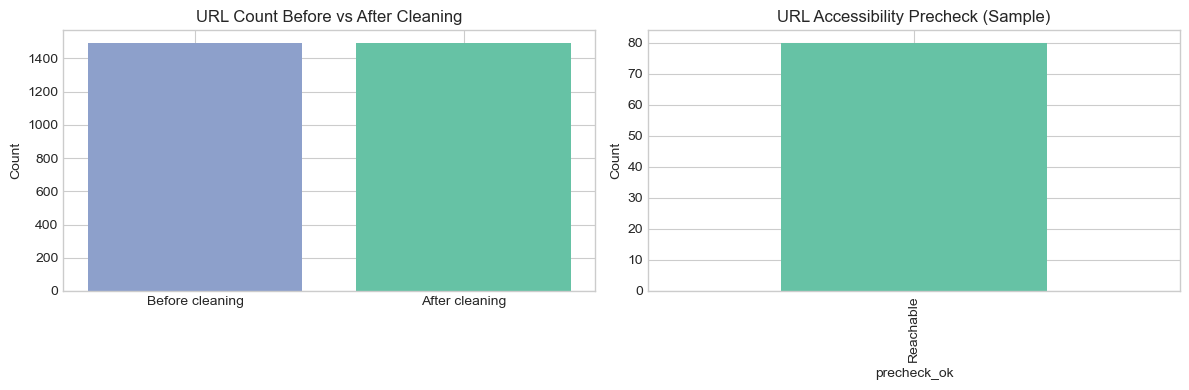

In [4]:
def normalize_url(u: str) -> str:
    u = u.strip()
    if not u.startswith('http'):
        return ''
    u = re.sub(r'#.*$', '', u)
    u = re.sub(r'\?.*$', '', u)
    u = u.rstrip('/')
    return u

# Before/after cleaning comparison
before_n = len(df_urls)
cleaned = df_urls.copy()
cleaned['url'] = cleaned['url_raw'].map(normalize_url)
cleaned = cleaned[cleaned['url'].str.startswith('https://www.businessnewsdaily.com/', na=False)]
cleaned = cleaned.drop_duplicates(subset=['url']).reset_index(drop=True)
after_n = len(cleaned)

print('Before cleaning:', before_n)
print('After cleaning (dedup + filter):', after_n)
display(cleaned.head(10))

# Lightweight accessibility precheck (sample + short timeout)
def precheck(client: httpx.Client, url: str, timeout: int = 5):
    t0 = time.perf_counter()
    status_code, ok, method_used = None, False, 'HEAD'
    try:
        r = client.head(url, timeout=timeout, follow_redirects=True)
        status_code = r.status_code
        ok = 200 <= r.status_code < 400
        if r.status_code in (403, 405):
            method_used = 'GET_fallback'
            r2 = client.get(url, timeout=timeout, follow_redirects=True)
            status_code = r2.status_code
            ok = 200 <= r2.status_code < 400
    except Exception:
        ok = False
    dt = time.perf_counter() - t0
    return ok, status_code, method_used, dt

precheck_rows = []
sample_for_precheck = cleaned['url'].head(min(80, len(cleaned)))
with httpx.Client() as client:
    for u in sample_for_precheck:
        ok, code, method, dt = precheck(client, u)
        precheck_rows.append({'url': u, 'precheck_ok': ok, 'precheck_code': code, 'method': method, 'latency_s': dt})

df_pre = pd.DataFrame(precheck_rows)
display(df_pre.head())

# Visualization: before/after cleaning + accessibility
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Before cleaning', 'After cleaning'], [before_n, after_n], color=['#8da0cb', '#66c2a5'])
axes[0].set_title('URL Count Before vs After Cleaning')
axes[0].set_ylabel('Count')

if len(df_pre) > 0:
    df_pre['precheck_ok'].value_counts().rename({True: 'Reachable', False: 'Unreachable'}).plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62'])
    axes[1].set_title('URL Accessibility Precheck (Sample)')
    axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 3) 并发抓取 HTML

In [5]:
async def fetch_one(client: httpx.AsyncClient, sem: asyncio.Semaphore, url: str):
    ua_list = [
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
        'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'
    ]
    final = {
        'url': url,
        'status': 'error',
        'status_code': None,
        'elapsed_s': None,
        'retries': 0,
        'error': '',
        'html': ''
    }
    async with sem:
        for attempt in range(MAX_RETRIES + 1):
            t0 = time.perf_counter()
            try:
                headers = {'User-Agent': random.choice(ua_list)}
                r = await client.get(url, headers=headers, timeout=REQUEST_TIMEOUT, follow_redirects=True)
                dt = time.perf_counter() - t0
                final.update({
                    'status': 'ok' if 200 <= r.status_code < 400 else 'http_error',
                    'status_code': r.status_code,
                    'elapsed_s': dt,
                    'retries': attempt,
                    'error': '',
                    'html': r.text if 200 <= r.status_code < 400 else ''
                })
                break
            except Exception as e:
                dt = time.perf_counter() - t0
                final.update({'elapsed_s': dt, 'retries': attempt, 'error': str(e)[:300]})
                await asyncio.sleep((2 ** attempt) * BASE_DELAY)
        await asyncio.sleep(BASE_DELAY)
    return final


async def crawl_all(urls: list[str], concurrency: int = 12):
    sem = asyncio.Semaphore(concurrency)
    limits = httpx.Limits(max_keepalive_connections=concurrency, max_connections=concurrency * 2)
    async with httpx.AsyncClient(limits=limits) as client:
        tasks = [fetch_one(client, sem, u) for u in urls]
        results = []
        for coro in asyncio.as_completed(tasks):
            results.append(await coro)
            if len(results) % 100 == 0:
                print(f'已完成 {len(results)}/{len(tasks)}')
        return results

crawl_urls = cleaned['url'].tolist()
start_at = time.time()
crawl_results = await crawl_all(crawl_urls, concurrency=CONCURRENCY)
print(f'抓取完成: {len(crawl_results)} 条, 总耗时 {time.time() - start_at:.1f}s')

df_crawl = pd.DataFrame(crawl_results)
display(df_crawl.head())

已完成 100/1494
已完成 200/1494
已完成 300/1494
已完成 400/1494
已完成 500/1494
已完成 600/1494
已完成 700/1494
已完成 800/1494
已完成 900/1494
已完成 1000/1494
已完成 1100/1494
已完成 1200/1494
已完成 1300/1494
已完成 1400/1494
抓取完成: 1494 条, 总耗时 155.1s


,url,status,status_code,elapsed_s,retries,error,html
0,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,ok,200,1.601375,0,,"<!DOCTYPE html><html lang=""en"" class=""sofia_sans_6160958f-module__d_OwOa__variable""><head><meta charSet=""utf-8""/><me..."
1,https://www.businessnewsdaily.com/6012-tax-tips-for-small-businesses.html,ok,200,1.604618,0,,"<!DOCTYPE html><html lang=""en"" class=""sofia_sans_6160958f-module__d_OwOa__variable""><head><meta charSet=""utf-8""/><me..."
2,https://www.businessnewsdaily.com/10960-ccpa-small-business-impact.html,ok,200,1.612645,0,,"<!DOCTYPE html><html lang=""en"" class=""sofia_sans_6160958f-module__d_OwOa__variable""><head><meta charSet=""utf-8""/><me..."
3,https://www.businessnewsdaily.com/11035-how-to-use-x11-forwarding.html,ok,200,1.654743,0,,"<!DOCTYPE html><html lang=""en"" class=""sofia_sans_6160958f-module__d_OwOa__variable""><head><meta charSet=""utf-8""/><me..."
4,https://www.businessnewsdaily.com/5942-tax-solutions-small-businesses.html,ok,200,1.668564,0,,"<!DOCTYPE html><html lang=""en"" class=""sofia_sans_6160958f-module__d_OwOa__variable""><head><meta charSet=""utf-8""/><me..."


## 4) 抓取过程可视化（状态码、耗时、批次成功率）

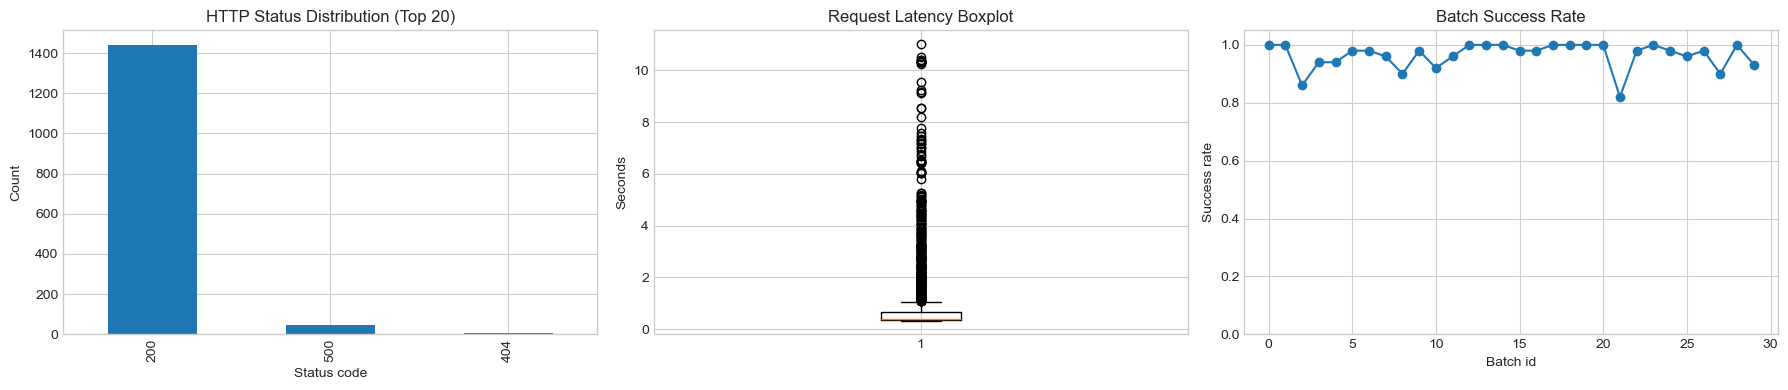

status
ok            1441
http_error      53
Name: count, dtype: int64


In [ ]:
# HTTP status distribution
status_dist = df_crawl['status_code'].fillna(-1).astype(int).value_counts().head(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
status_dist.plot(kind='bar', ax=axes[0], title='HTTP Status Distribution')
axes[0].set_xlabel('Status code')
axes[0].set_ylabel('Count')

# Request latency boxplot
valid_elapsed = df_crawl.loc[df_crawl['elapsed_s'].notna(), 'elapsed_s']
axes[1].boxplot(valid_elapsed.values, vert=True)
axes[1].set_title('Request Latency Boxplot')
axes[1].set_ylabel('Seconds')

# Batch-level success rate
batch_size = 50
tmp = df_crawl.copy()
tmp['ok'] = tmp['status'].eq('ok').astype(int)
tmp['batch_id'] = np.arange(len(tmp)) // batch_size
batch_ok = tmp.groupby('batch_id')['ok'].mean()
axes[2].plot(batch_ok.index, batch_ok.values, marker='o')
axes[2].set_ylim(0, 1.05)
axes[2].set_title('Batch Success Rate')
axes[2].set_xlabel('Batch id')
axes[2].set_ylabel('Success rate')

plt.tight_layout()
plt.show()

print(df_crawl['status'].value_counts(dropna=False))

## 5) 正文解析与元数据抽取（标题、发布时间、作者）

In [7]:
def safe_text(x: str) -> str:
    return re.sub(r'\s+', ' ', x or '').strip()


def build_soup(html_text: str) -> BeautifulSoup:
    # 优先使用 lxml；环境缺失时自动回退到内置 html.parser
    try:
        return BeautifulSoup(html_text, 'lxml')
    except Exception:
        return BeautifulSoup(html_text, 'html.parser')


def parse_json_ld(soup: BeautifulSoup) -> dict:
    out = {'title_ld': '', 'date_published': '', 'date_modified': '', 'author': ''}
    for tag in soup.find_all('script', attrs={'type': 'application/ld+json'}):
        txt = (tag.string or '').strip()
        if not txt:
            continue
        try:
            data = json.loads(txt)
        except Exception:
            continue
        payloads = data if isinstance(data, list) else [data]
        for p in payloads:
            if not isinstance(p, dict):
                continue
            if p.get('@type') in {'NewsArticle', 'Article'}:
                out['title_ld'] = p.get('headline') or out['title_ld']
                out['date_published'] = p.get('datePublished') or out['date_published']
                out['date_modified'] = p.get('dateModified') or out['date_modified']
                author = p.get('author')
                if isinstance(author, dict):
                    out['author'] = author.get('name', '')
                elif isinstance(author, list):
                    out['author'] = ', '.join([a.get('name', '') for a in author if isinstance(a, dict)])
    return out


def extract_main_text(soup: BeautifulSoup) -> str:
    # 优先 article/main 容器
    candidates = soup.select('article, main, div')
    best_text = ''
    for node in candidates:
        ps = [safe_text(p.get_text(' ', strip=True)) for p in node.find_all('p')]
        ps = [p for p in ps if len(p) >= 35]
        text = '\n\n'.join(dict.fromkeys(ps))
        if len(text) > len(best_text):
            best_text = text
    return best_text

parsed_rows = []
for _, row in df_crawl.iterrows():
    if row['status'] != 'ok' or not row['html']:
        parsed_rows.append({
            'url': row['url'], 'title': '', 'author': '', 'date_published': '',
            'date_modified': '', 'content_raw': '', 'parse_ok': False
        })
        continue

    soup = build_soup(row['html'])
    ld = parse_json_ld(soup)
    h1 = soup.find('h1')
    title = safe_text(h1.get_text(' ', strip=True)) if h1 else ''
    title = title or ld['title_ld']
    content_raw = extract_main_text(soup)

    parsed_rows.append({
        'url': row['url'],
        'title': title,
        'author': ld['author'],
        'date_published': ld['date_published'],
        'date_modified': ld['date_modified'],
        'content_raw': content_raw,
        'parse_ok': len(content_raw) > 0
    })

df_parsed = pd.DataFrame(parsed_rows)
parse_rate = df_parsed['parse_ok'].mean() if len(df_parsed) else 0
print(f'解析成功率: {parse_rate:.2%}')
display(df_parsed.head())

# 原始 HTML 片段 vs 提取正文（随机 3 条）
ok_urls = df_parsed[df_parsed['parse_ok']]['url'].tolist()
sample_urls = random.sample(ok_urls, k=min(3, len(ok_urls))) if ok_urls else []
for u in sample_urls:
    html_text = df_crawl.loc[df_crawl['url'] == u, 'html'].iloc[0]
    content_text = df_parsed.loc[df_parsed['url'] == u, 'content_raw'].iloc[0]
    print('\n' + '=' * 90)
    print('URL:', u)
    print('[HTML片段前500字符]\n', safe_text(html_text)[:500])
    print('\n[正文片段前500字符]\n', safe_text(content_text)[:500])

解析成功率: 96.45%


,url,title,author,date_published,date_modified,content_raw,parse_ok
0,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,Kiely Kuligowski,2020-10-12T11:30:00Z,2025-05-21T18:47:21Z,Email marketing is a great way to engage with and learn about your customers. Drip campaigns make the process easy b...,True
1,https://www.businessnewsdaily.com/6012-tax-tips-for-small-businesses.html,Small Business Tax Tips,Sally Herigstad,2014-03-04T23:01:00Z,2023-10-23T22:57:06Z,"For people running small businesses, taking care of business tax obligations can seem like a daunting task. For many...",True
2,https://www.businessnewsdaily.com/10960-ccpa-small-business-impact.html,How California’s Consumer Privacy Act Affects Your Business,Max Freedman,2019-12-31T16:00:00Z,2023-12-20T16:12:26Z,"Although the California Consumer Privacy Act (CCPA) technically applies only to the Golden State, California residen...",True
3,https://www.businessnewsdaily.com/11035-how-to-use-x11-forwarding.html,How to Set Up and Use X11 Forwarding on Linux and Mac,Adam Uzialko,2018-09-06T19:30:00Z,2023-12-20T16:13:51Z,Tech-savvy users know you can easily connect to a Linux server using various secure shell (SSH) clients. If you pref...,True
4,https://www.businessnewsdaily.com/5942-tax-solutions-small-businesses.html,10 Tax Solutions for Small Businesses,Sally Herigstad,2014-03-21T20:00:00Z,2023-10-23T22:52:17Z,Entrepreneurs and small business owners often face complicated tax obligations. With so many other duties related to...,True



URL: https://www.businessnewsdaily.com/10177-direct-sales-career.html
[HTML片段前500字符]
 <!DOCTYPE html><html lang="en" class="sofia_sans_6160958f-module__d_OwOa__variable"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, shrink-to-fit=no, initial-scale=1"/><link rel="stylesheet" href="/_next/static/chunks/0uoavcmnsdb59.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/chunks/0sqa6-71nkqku.css" data-precedence="next"/><link rel="stylesheet" href="/_next/static/chunks/0ley3jx.l-49..css" data-precedence="next"/><link rel="stylesheet

[正文片段前500字符]
 Working from home, setting your own hours, being your own boss and earning high commissions – who wouldn’t want to work in direct sales? If you’ve been listening to friends, relatives or social media influencers sing the praises of their newfound careers in direct sales, you’re probably wondering if you should get in on the action. On the flip side, though, every few years it seems like there’s

## 6) 抽取质量检查与异常样本可视化

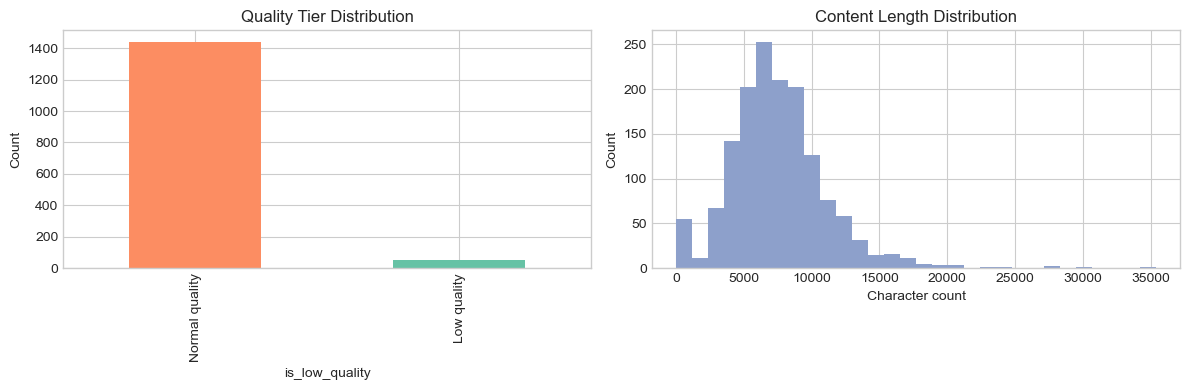

,url,title,char_count,dup_para_rate,noise_ratio
113,https://www.businessnewsdaily.com/16297-adp-vs-paychex-payroll.html,,0,0.0,0.0
121,https://www.businessnewsdaily.com/2174-guerilla-marketing-wrong.html,,0,0.0,0.0
127,https://www.businessnewsdaily.com/10600-business-ideas-travel-lovers.html,,0,0.0,0.0
129,https://www.businessnewsdaily.com/15173-combat-workplace-burnout.html,,0,0.0,0.0
130,https://www.businessnewsdaily.com/employee-turnover-costs-retention-tips,,0,0.0,0.0
136,https://www.businessnewsdaily.com/10564-best-b2b-billing-practices.html,,0,0.0,0.0
139,https://www.businessnewsdaily.com/16588-15-accounting-payment-terms-strategies.html,,0,0.0,0.0
156,https://www.businessnewsdaily.com/16586-ringcentral-vs-dialpad.html,,0,0.0,0.0
166,https://www.businessnewsdaily.com/983-product-placement-guide.html,,0,0.0,0.0
185,https://www.businessnewsdaily.com/15925-what-is-holiday-pay.html,,0,0.0,0.0


In [8]:
def quality_metrics(text: str):
    t = text or ''
    paragraphs = [x for x in t.split('\n\n') if x.strip()]
    duplicate_rate = 1 - (len(set(paragraphs)) / len(paragraphs)) if paragraphs else 0
    noise_tokens = ['Related', 'Share', 'Recommended', 'Advertisement', 'Editorial Guidelines']
    noise_ratio = sum(t.count(tok) for tok in noise_tokens) / max(len(t), 1)
    return {
        'char_count': len(t),
        'para_count': len(paragraphs),
        'dup_para_rate': duplicate_rate,
        'noise_ratio': noise_ratio,
    }

q_rows = []
for _, r in df_parsed.iterrows():
    m = quality_metrics(r['content_raw'])
    bad = (
        (m['char_count'] < 800) or
        (m['dup_para_rate'] > 0.35) or
        (m['noise_ratio'] > 0.003) or
        (not r['title'])
    )
    q_rows.append({**r, **m, 'is_low_quality': bad})

df_q = pd.DataFrame(q_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_q['is_low_quality'].value_counts().rename({True: 'Low quality', False: 'Normal quality'}).plot(kind='bar', ax=axes[0], color=['#fc8d62', '#66c2a5'])
axes[0].set_title('Quality Tier Distribution')
axes[0].set_ylabel('Count')

axes[1].hist(df_q['char_count'].fillna(0), bins=30, color='#8da0cb')
axes[1].set_title('Content Length Distribution')
axes[1].set_xlabel('Character count')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

low_quality_samples = df_q[df_q['is_low_quality']].sort_values(['char_count']).head(20)[['url', 'title', 'char_count', 'dup_para_rate', 'noise_ratio']]
display(low_quality_samples)

## 7) 文本清洗与结构化整理

,url,url_hash,title,author,date_published,date_modified,content,char_count_clean,status,parse_ok,is_low_quality,crawl_time_utc
0,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,28dc81493712a9c8883c52c1881b6fbeb6ec6422,How to Develop Successful Email Drip Campaigns,Kiely Kuligowski,2020-10-12T11:30:00Z,2025-05-21T18:47:21Z,Email marketing is a great way to engage with and learn about your customers. Drip campaigns make the process easy b...,14321,ok,True,False,2026-03-27T09:51:34.421499+00:00
1,https://www.businessnewsdaily.com/6012-tax-tips-for-small-businesses.html,69323644cd37e19b2ad2af4073a5a2b7c5a0fc12,Small Business Tax Tips,Sally Herigstad,2014-03-04T23:01:00Z,2023-10-23T22:57:06Z,"For people running small businesses, taking care of business tax obligations can seem like a daunting task. For many...",10479,ok,True,False,2026-03-27T09:51:34.421499+00:00
2,https://www.businessnewsdaily.com/10960-ccpa-small-business-impact.html,509792dc14fb85933773e3a1f94a7b2a8002b38d,How California’s Consumer Privacy Act Affects Your Business,Max Freedman,2019-12-31T16:00:00Z,2023-12-20T16:12:26Z,"Although the California Consumer Privacy Act (CCPA) technically applies only to the Golden State, California residen...",5467,ok,True,False,2026-03-27T09:51:34.421499+00:00
3,https://www.businessnewsdaily.com/11035-how-to-use-x11-forwarding.html,05ec9af1af73656dc85a76e37a31fe66f95050fe,How to Set Up and Use X11 Forwarding on Linux and Mac,Adam Uzialko,2018-09-06T19:30:00Z,2023-12-20T16:13:51Z,Tech-savvy users know you can easily connect to a Linux server using various secure shell (SSH) clients. If you pref...,2595,ok,True,False,2026-03-27T09:51:34.421499+00:00
4,https://www.businessnewsdaily.com/5942-tax-solutions-small-businesses.html,44e1052d9cb17d895a312c244935f668f5582ffb,10 Tax Solutions for Small Businesses,Sally Herigstad,2014-03-21T20:00:00Z,2023-10-23T22:52:17Z,Entrepreneurs and small business owners often face complicated tax obligations. With so many other duties related to...,8012,ok,True,False,2026-03-27T09:51:34.421499+00:00
5,https://www.businessnewsdaily.com/8311-remote-work-is-commonplace.html,85deb4dbb1ba138a7d28e47c13b411e95a85d22a,Are Remote Employees Better Workers?,Casey Conway,2021-10-07T19:36:00Z,2024-05-17T14:24:52Z,"Remote work may have moved to center stage during the pandemic, but the demand for it is here to stay. Many employee...",6810,ok,True,False,2026-03-27T09:51:34.421499+00:00
6,https://www.businessnewsdaily.com/5936-can-smartphones-actually-make-employees-more-productive.html,ba42300760142507ada40210188761b6cfcf4ccd,Mobile Device Usage at Work Increases Productivity,Max Freedman,2021-11-09T16:26:00Z,2023-10-23T22:51:50Z,"In recent years, many companies have loosened their rules on in-office personal phone use. For most employers, it’s ...",2885,ok,True,False,2026-03-27T09:51:34.421499+00:00
7,https://www.businessnewsdaily.com/11137-how-to-become-a-coo.html,8c57c916cad2e6b564fdadeb8c921cde3d7c9e83,How to Become a Chief Operating Officer (COO),Adam Uzialko,2019-11-13T18:30:00Z,2023-12-20T16:15:23Z,"When it comes to a company’s C-suite executives, the chief operating officer (COO) is a crucial yet often misunderst...",3518,ok,True,False,2026-03-27T09:51:34.421499+00:00
8,https://www.businessnewsdaily.com/5709-android-accounting-finance-apps-small-business.html,77f7d0f675f776c95305a26c8c8a224cbcb28e32,The 7 Best Small Business Accounting Apps,Adam Uzialko,2018-12-05T03:12:00Z,2023-11-08T00:00:00+00:00,"Mobile apps allow you to take parts of your life with you wherever you go, including your business. Accounting apps,...",9550,ok,True,False,2026-03-27T09:51:34.421499+00:00
9,https://www.businessnewsdaily.com/freshbooks-vs-xero,f9f4e7f16ddb4eaf51e1ebbe7ca88c7c92692f64,FreshBooks vs. Xero Comparison,Tom Anziano,2023-07-20T13:34:53Z,2025-01-14T20:23:05Z,Check out The Best Accounting Software Services for Self-Employed and Freelancers in 2026 business.com recommends. A...,7758,ok,True,Fal

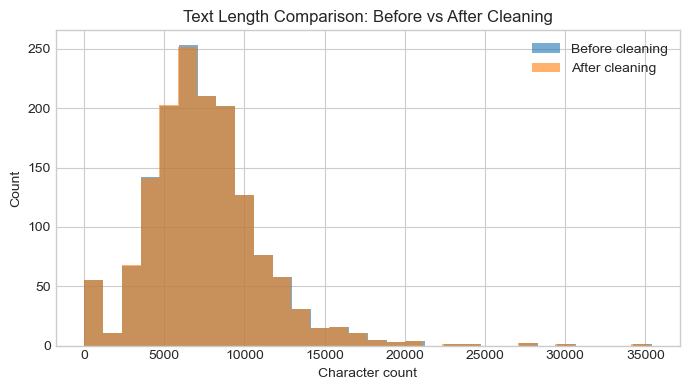

In [9]:
def clean_content(t: str) -> str:
    if not isinstance(t, str):
        return ''
    # Remove common navigation/noise phrases
    t = re.sub(r'(Related Articles|Related Reviews|Did you find this content helpful\??)', ' ', t, flags=re.I)
    t = re.sub(r'\s+', ' ', t)
    return t.strip()

structured = df_q.copy()
structured['content'] = structured['content_raw'].map(clean_content)
structured['char_count_clean'] = structured['content'].str.len()
structured['status'] = np.where(structured['is_low_quality'], 'low_quality', 'ok')
structured['crawl_time_utc'] = datetime.now(timezone.utc).isoformat()
structured['url_hash'] = structured['url'].map(lambda x: hashlib.sha1(x.encode('utf-8')).hexdigest() if isinstance(x, str) else '')

cols = ['url', 'url_hash', 'title', 'author', 'date_published', 'date_modified', 'content', 'char_count_clean', 'status', 'parse_ok', 'is_low_quality', 'crawl_time_utc']
df_structured = structured[cols].copy()

display(df_structured.head(10))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(structured['char_count'].fillna(0), bins=30, alpha=0.6, label='Before cleaning')
ax.hist(structured['char_count_clean'].fillna(0), bins=30, alpha=0.6, label='After cleaning')
ax.set_title('Text Length Comparison: Before vs After Cleaning')
ax.set_xlabel('Character count')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 8) 主题与长度分布可视化

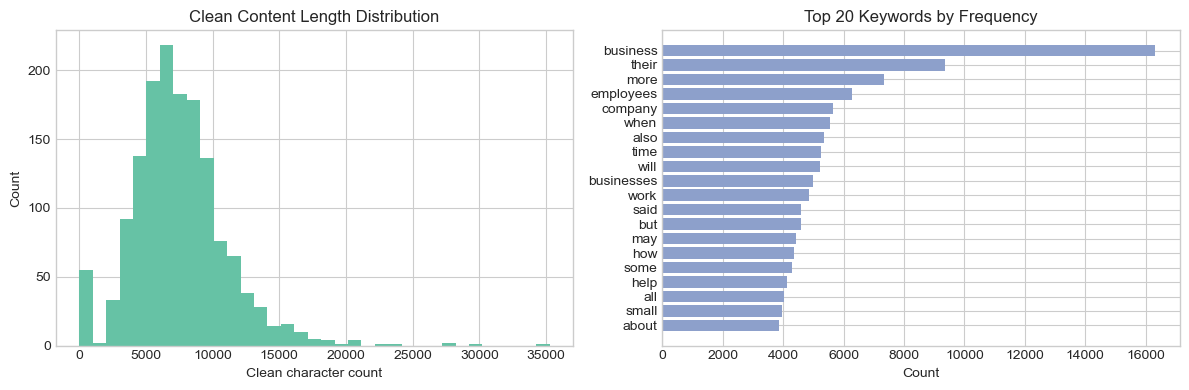

C:\Users\15038\AppData\Local\Temp\ipykernel_10748\2772494583.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


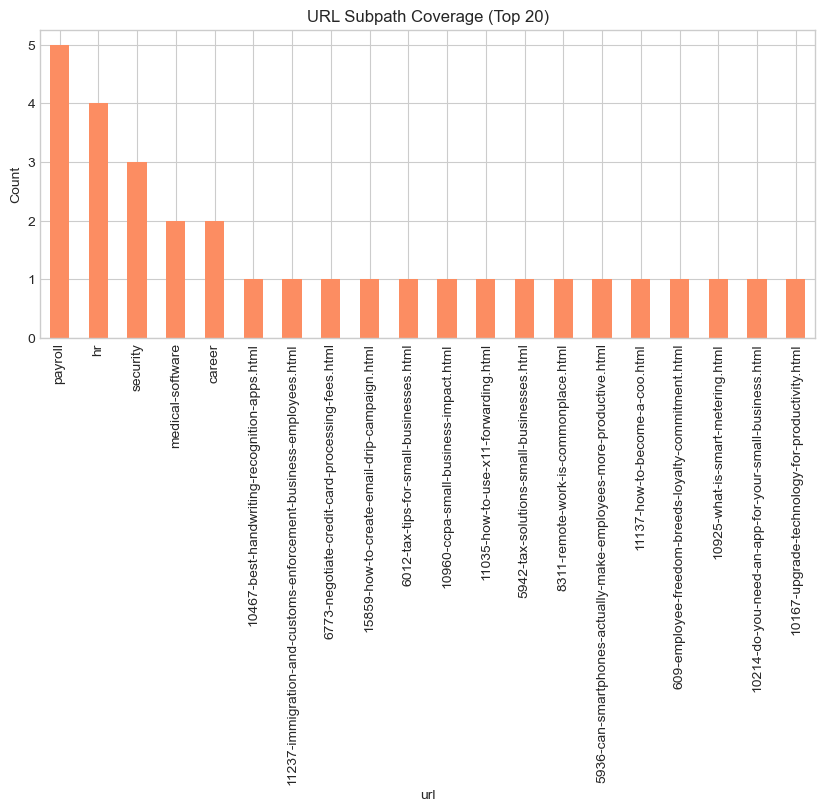

In [10]:
# Length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_structured['char_count_clean'].fillna(0), bins=35, color='#66c2a5')
axes[0].set_title('Clean Content Length Distribution')
axes[0].set_xlabel('Clean character count')
axes[0].set_ylabel('Count')

# Basic keyword frequency (lightweight English stopword list)
stopwords = set('the a an and or of to in for with on at by from as is are was were be this that these those your our you we they it its have has had not no yes can could should would'.split())
text_all = ' '.join(df_structured['content'].fillna('').tolist()).lower()
words = re.findall(r'[a-z]{3,}', text_all)
words = [w for w in words if w not in stopwords]
word_top = Counter(words).most_common(20)

if word_top:
    k_df = pd.DataFrame(word_top, columns=['word', 'count'])
    axes[1].barh(k_df['word'][::-1], k_df['count'][::-1], color='#8da0cb')
    axes[1].set_title('Top 20 Keywords by Frequency')
    axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# URL subpath coverage
subpath = df_structured['url'].str.replace('https://www.businessnewsdaily.com/', '', regex=False).str.split('/').str[0]
sub_count = subpath.value_counts().head(20)
plt.figure(figsize=(10, 4))
sub_count.plot(kind='bar', title='URL Subpath Coverage (Top 20)', color='#fc8d62')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 9) 结果落盘（Raw/Processed）与失败重试清单导出

Parquet export failed (usually missing pyarrow/fastparquet): Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
Output files:
- e:\研究生资料\7102\project\data\dataset_businessnewsdaily\raw\crawl_log.csv
- e:\研究生资料\7102\project\data\dataset_businessnewsdaily\raw\raw_pages.jsonl
- e:\研究生资料\7102\project\data\dataset_businessnewsdaily\clean\clean_articles.csv
- e:\研究生资料\7102\project\data\dataset_businessnewsdaily\clean\clean_articles.jsonl
- parquet not generated
- e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\failed_urls_retry_list.csv


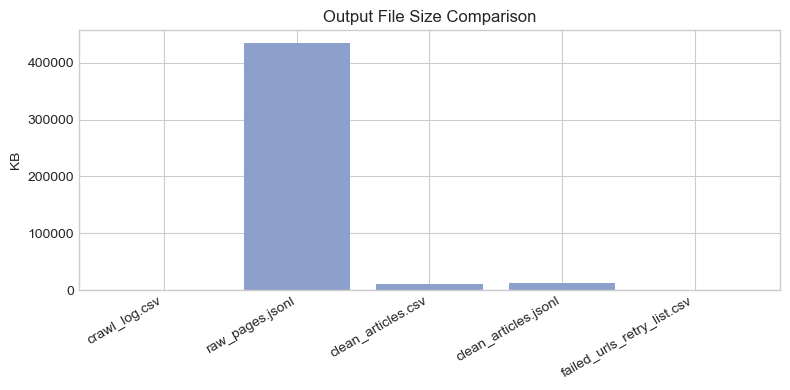

,file,size_kb
0,crawl_log.csv,147.40
1,raw_pages.jsonl,435073.23
2,clean_articles.csv,11441.83
3,clean_articles.jsonl,11710.42
4,failed_urls_retry_list.csv,4.59


ok rows: 1441 | failed rows: 53


In [11]:
# Save raw outputs
raw_log_path = RAW_DIR / 'crawl_log.csv'
raw_jsonl_path = RAW_DIR / 'raw_pages.jsonl'
df_crawl.drop(columns=['html']).to_csv(raw_log_path, index=False, encoding='utf-8-sig')

with raw_jsonl_path.open('w', encoding='utf-8') as f:
    for _, r in df_crawl.iterrows():
        f.write(json.dumps({'url': r['url'], 'status_code': r['status_code'], 'html': r['html']}, ensure_ascii=False) + '\n')

# Save processed outputs
processed_csv = CLEAN_DIR / 'clean_articles.csv'
processed_jsonl = CLEAN_DIR / 'clean_articles.jsonl'
processed_parquet = CLEAN_DIR / 'clean_articles.parquet'

ok_df = df_structured[df_structured['status'] == 'ok'].copy()
ok_df.to_csv(processed_csv, index=False, encoding='utf-8-sig')
with processed_jsonl.open('w', encoding='utf-8') as f:
    for _, r in ok_df.iterrows():
        f.write(json.dumps(r.to_dict(), ensure_ascii=False) + '\n')

parquet_ok = True
try:
    ok_df.to_parquet(processed_parquet, index=False)
except Exception as e:
    parquet_ok = False
    print('Parquet export failed (usually missing pyarrow/fastparquet):', e)

# Failed URL list for retry
failed_df = df_crawl[df_crawl['status'] != 'ok'][['url', 'status', 'status_code', 'error', 'retries']].copy()
failed_path = REPORT_DIR / 'failed_urls_retry_list.csv'
failed_df.to_csv(failed_path, index=False, encoding='utf-8-sig')

print('Output files:')
print('-', raw_log_path)
print('-', raw_jsonl_path)
print('-', processed_csv)
print('-', processed_jsonl)
print('-', processed_parquet if parquet_ok else 'parquet not generated')
print('-', failed_path)

# Compare output file sizes
size_rows = []
for p in [raw_log_path, raw_jsonl_path, processed_csv, processed_jsonl, failed_path]:
    if p.exists():
        size_rows.append({'file': p.name, 'size_kb': round(p.stat().st_size / 1024, 2)})

df_size = pd.DataFrame(size_rows)
if len(df_size):
    plt.figure(figsize=(8, 4))
    plt.bar(df_size['file'], df_size['size_kb'], color='#8da0cb')
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('KB')
    plt.title('Output File Size Comparison')
    plt.tight_layout()
    plt.show()

display(df_size)
print('ok rows:', len(ok_df), '| failed rows:', len(failed_df))

## 10) 增量爬取与断点续跑机制

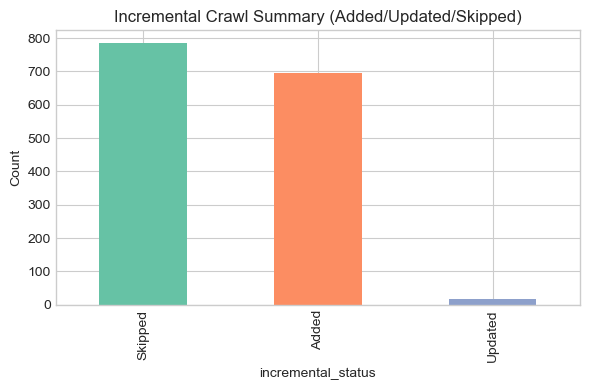

Incremental candidates (Added + Updated): 710
Average request latency (s): 1.014
Estimated incremental total time (s): 719.9


,url,url_hash,date_modified,snapshot_time,incremental_status
0,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,28dc81493712a9c8883c52c1881b6fbeb6ec6422,2025-05-21T18:47:21Z,2026-03-27T09:51:38.455458+00:00,Added
1,https://www.businessnewsdaily.com/6012-tax-tips-for-small-businesses.html,69323644cd37e19b2ad2af4073a5a2b7c5a0fc12,2023-10-23T22:57:06Z,2026-03-27T09:51:38.455458+00:00,Skipped
2,https://www.businessnewsdaily.com/10960-ccpa-small-business-impact.html,509792dc14fb85933773e3a1f94a7b2a8002b38d,2023-12-20T16:12:26Z,2026-03-27T09:51:38.455458+00:00,Skipped
3,https://www.businessnewsdaily.com/11035-how-to-use-x11-forwarding.html,05ec9af1af73656dc85a76e37a31fe66f95050fe,2023-12-20T16:13:51Z,2026-03-27T09:51:38.455458+00:00,Skipped
4,https://www.businessnewsdaily.com/5942-tax-solutions-small-businesses.html,44e1052d9cb17d895a312c244935f668f5582ffb,2023-10-23T22:52:17Z,2026-03-27T09:51:38.455458+00:00,Skipped
5,https://www.businessnewsdaily.com/8311-remote-work-is-commonplace.html,85deb4dbb1ba138a7d28e47c13b411e95a85d22a,2024-05-17T14:24:52Z,2026-03-27T09:51:38.455458+00:00,Added
6,https://www.businessnewsdaily.com/5936-can-smartphones-actually-make-employees-more-productive.html,ba42300760142507ada40210188761b6cfcf4ccd,2023-10-23T22:51:50Z,2026-03-27T09:51:38.455458+00:00,Skipped
7,https://www.businessnewsdaily.com/11137-how-to-become-a-coo.html,8c57c916cad2e6b564fdadeb8c921cde3d7c9e83,2023-12-20T16:15:23Z,2026-03-27T09:51:38.455458+00:00,Skipped
8,https://www.businessnewsdaily.com/5709-android-accounting-finance-apps-small-business.html,77f7d0f675f776c95305a26c8c8a224cbcb28e32,2023-11-08T00:00:00+00:00,2026-03-27T09:51:38.455458+00:00,Added
9,https://www.businessnewsdaily.com/freshbooks-vs-xero,f9f4e7f16ddb4eaf51e1ebbe7ca88c7c92692f64,2025-01-14T20:23:05Z,2026-03-27T09:51:38.455458+00:00,Added


In [12]:
# Incremental strategy based on URL hash + date_modified
manifest_path = REPORT_DIR / 'crawl_manifest.csv'

current_manifest = df_structured[['url', 'url_hash', 'date_modified']].copy()
current_manifest['snapshot_time'] = datetime.now(timezone.utc).isoformat()

if manifest_path.exists():
    old_manifest = pd.read_csv(manifest_path)
else:
    old_manifest = pd.DataFrame(columns=['url', 'url_hash', 'date_modified', 'snapshot_time'])

old_map = old_manifest.set_index('url')['date_modified'].to_dict() if len(old_manifest) else {}

def inc_status(row):
    u = row['url']
    dm = row['date_modified'] if pd.notna(row['date_modified']) else ''
    if u not in old_map:
        return 'Added'
    if str(old_map.get(u, '')) != str(dm):
        return 'Updated'
    return 'Skipped'

current_manifest['incremental_status'] = current_manifest.apply(inc_status, axis=1)
inc_stat = current_manifest['incremental_status'].value_counts()

plt.figure(figsize=(6, 4))
inc_stat.plot(kind='bar', color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Incremental Crawl Summary (Added/Updated/Skipped)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Save new snapshot
current_manifest.to_csv(manifest_path, index=False, encoding='utf-8-sig')

# Estimate incremental crawl time
avg_elapsed = df_crawl['elapsed_s'].dropna().mean() if df_crawl['elapsed_s'].notna().any() else np.nan
candidates = current_manifest[current_manifest['incremental_status'].isin(['Added', 'Updated'])]
est_seconds = len(candidates) * (avg_elapsed if pd.notna(avg_elapsed) else 0)

print('Incremental candidates (Added + Updated):', len(candidates))
print('Average request latency (s):', round(avg_elapsed, 3) if pd.notna(avg_elapsed) else 'N/A')
print('Estimated incremental total time (s):', round(est_seconds, 1))
display(current_manifest.head(10))

## 11) 汇报PPT流程模板（可直接复制）

建议 8 页：
1. 项目目标与数据来源
2. URL 清洗与可访问性预检
3. 并发抓取策略（重试、限速、超时）
4. 抓取效果（状态码/耗时/成功率）
5. 正文与元数据抽取效果
6. 质量检查与异常样本复核
7. 结构化数据与落盘结果
8. RAG 准备（单文档存储、分块、增量更新）

In [13]:
ppt_outline = pd.DataFrame(
    [
        ['P1', '项目目标与数据来源', 'BusinessNewsDaily URL 总量、样本范围、抓取边界'],
        ['P2', 'URL 清洗与预检', '清洗前后数量、可访问比例图'],
        ['P3', '并发抓取策略', '并发数、重试、超时、UA、限速'],
        ['P4', '抓取结果可视化', '状态码分布、耗时箱线图、批次成功率'],
        ['P5', '正文与元数据抽取', '标题/作者/日期抽取成功率、示例对比'],
        ['P6', '质量检查', '低质量样本判定规则与异常案例'],
        ['P7', '结构化落盘', 'raw/clean 文件、失败清单、文件体积'],
        ['P8', 'RAG 数据准备', '单文章文件+chunk 统计+增量更新策略'],
    ],
    columns=['页码', '标题', '核心内容'],
)

display(ppt_outline)
ppt_outline.to_csv(REPORT_DIR / 'ppt_outline.csv', index=False, encoding='utf-8-sig')
print('已导出:', REPORT_DIR / 'ppt_outline.csv')

,页码,标题,核心内容
0,P1,项目目标与数据来源,BusinessNewsDaily URL 总量、样本范围、抓取边界
1,P2,URL 清洗与预检,清洗前后数量、可访问比例图
2,P3,并发抓取策略,并发数、重试、超时、UA、限速
3,P4,抓取结果可视化,状态码分布、耗时箱线图、批次成功率
4,P5,正文与元数据抽取,标题/作者/日期抽取成功率、示例对比
5,P6,质量检查,低质量样本判定规则与异常案例
6,P7,结构化落盘,raw/clean 文件、失败清单、文件体积
7,P8,RAG 数据准备,单文章文件+chunk 统计+增量更新策略


已导出: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\ppt_outline.csv


## 12) RAG 预处理：单文章文件存储与分块

是的，做 RAG 建议分块。

这里会完成：
- 每篇文章单独保存到文件夹（json + txt）
- 生成 chunk 级数据（jsonl/csv）
- 统计每篇文章的 chunk 数与 chunk 长度分布

Usable documents: 1441
Total chunks: 16942
Article directory: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\clean\article_docs
Chunk directory: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\clean\rag_chunks


,doc_id,url,title,char_count,chunk_count
0,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,14321,22
1,doc_00002,https://www.businessnewsdaily.com/6012-tax-tips-for-small-businesses.html,Small Business Tax Tips,10479,15
2,doc_00003,https://www.businessnewsdaily.com/10960-ccpa-small-business-impact.html,How California’s Consumer Privacy Act Affects Your Business,5467,9
3,doc_00004,https://www.businessnewsdaily.com/11035-how-to-use-x11-forwarding.html,How to Set Up and Use X11 Forwarding on Linux and Mac,2595,4
4,doc_00005,https://www.businessnewsdaily.com/5942-tax-solutions-small-businesses.html,10 Tax Solutions for Small Businesses,8012,12


,chunk_id,doc_id,url,title,chunk_index,chunk_len,chunk_text
0,doc_00001_chunk_001,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,1,771,Email marketing is a great way to engage with and learn about your customers. Drip campaigns make the process easy b...
1,doc_00001_chunk_002,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,2,883,sent automatically based on a set schedule or user action. Drip campaigns aim to deliver the right information to th...
2,doc_00001_chunk_003,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,3,802,"s are a great way to stay top of mind with your current and potential clients,” said Sir Sanju Ganglani, the chief m..."
3,doc_00001_chunk_004,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,4,835,"igures for all marketing emails sent in North America – 23.53% and 3.86%, respectively. Here are six simple steps fo..."
4,doc_00001_chunk_005,doc_00001,https://www.businessnewsdaily.com/15859-how-to-create-email-drip-campaign.html,How to Develop Successful Email Drip Campaigns,5,877,demographic trigger could be a user’s birthday that prompts an email wishing them a happy birthday from your company...


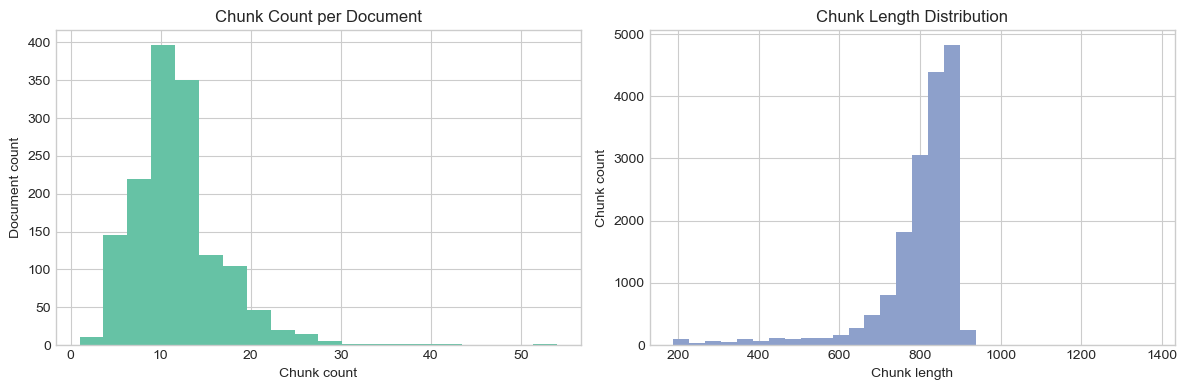

In [14]:
ARTICLE_DIR = CLEAN_DIR / 'article_docs'
CHUNK_DIR = CLEAN_DIR / 'rag_chunks'
ARTICLE_DIR.mkdir(parents=True, exist_ok=True)
CHUNK_DIR.mkdir(parents=True, exist_ok=True)

# Keep only RAG-ready documents
rag_df = df_structured[df_structured['status'] == 'ok'].copy()
rag_df = rag_df[rag_df['content'].fillna('').str.len() >= 300].copy().reset_index(drop=True)
rag_df['doc_id'] = [f'doc_{i+1:05d}' for i in range(len(rag_df))]


def chunk_text(text: str, chunk_size: int = 900, overlap: int = 150):
    text = (text or '').strip()
    if not text:
        return []

    # Split by sentence first, then merge into near-chunk_size pieces
    sentences = re.split(r'(?<=[\.!?。！？])\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    cur = ''
    for s in sentences:
        if len(cur) + len(s) + 1 <= chunk_size:
            cur = f'{cur} {s}'.strip()
        else:
            if cur:
                chunks.append(cur)
            tail = cur[-overlap:] if cur and overlap > 0 else ''
            cur = f'{tail} {s}'.strip()
    if cur:
        chunks.append(cur)

    chunks = [c for c in chunks if len(c) >= 120]
    return chunks


article_index_rows = []
chunk_rows = []
for _, r in rag_df.iterrows():
    doc_id = r['doc_id']
    doc_obj = {
        'doc_id': doc_id,
        'url': r['url'],
        'title': r['title'],
        'author': r['author'],
        'date_published': r['date_published'],
        'date_modified': r['date_modified'],
        'content': r['content'],
    }

    # Store each article independently
    (ARTICLE_DIR / f'{doc_id}.json').write_text(json.dumps(doc_obj, ensure_ascii=False, indent=2), encoding='utf-8')
    (ARTICLE_DIR / f'{doc_id}.txt').write_text(r['content'], encoding='utf-8')

    chunks = chunk_text(r['content'], chunk_size=900, overlap=150)
    article_index_rows.append({'doc_id': doc_id, 'url': r['url'], 'title': r['title'], 'char_count': len(r['content']), 'chunk_count': len(chunks)})
    for i, c in enumerate(chunks, start=1):
        chunk_rows.append({
            'chunk_id': f'{doc_id}_chunk_{i:03d}',
            'doc_id': doc_id,
            'url': r['url'],
            'title': r['title'],
            'chunk_index': i,
            'chunk_len': len(c),
            'chunk_text': c,
        })

article_index_df = pd.DataFrame(article_index_rows)
chunk_df = pd.DataFrame(chunk_rows)

# Save outputs
article_index_df.to_csv(CHUNK_DIR / 'article_index.csv', index=False, encoding='utf-8-sig')
chunk_df.to_csv(CHUNK_DIR / 'chunks.csv', index=False, encoding='utf-8-sig')
with (CHUNK_DIR / 'chunks.jsonl').open('w', encoding='utf-8') as f:
    for _, rr in chunk_df.iterrows():
        f.write(json.dumps(rr.to_dict(), ensure_ascii=False) + '\n')

print('Usable documents:', len(article_index_df))
print('Total chunks:', len(chunk_df))
print('Article directory:', ARTICLE_DIR)
print('Chunk directory:', CHUNK_DIR)

display(article_index_df.head())
display(chunk_df.head())

# Visualize chunk count per document + chunk length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(article_index_df):
    axes[0].hist(article_index_df['chunk_count'], bins=20, color='#66c2a5')
    axes[0].set_title('Chunk Count per Document')
    axes[0].set_xlabel('Chunk count')
    axes[0].set_ylabel('Document count')
if len(chunk_df):
    axes[1].hist(chunk_df['chunk_len'], bins=30, color='#8da0cb')
    axes[1].set_title('Chunk Length Distribution')
    axes[1].set_xlabel('Chunk length')
    axes[1].set_ylabel('Chunk count')
plt.tight_layout()
plt.show()

## 13) PPT-ready figures with English labels

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\01_url_count_before_after.png


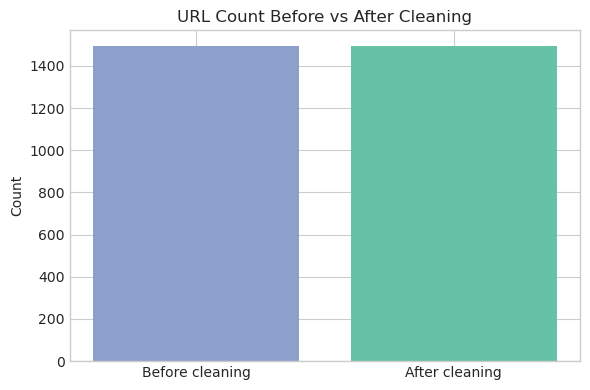

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\02_precheck_accessibility.png


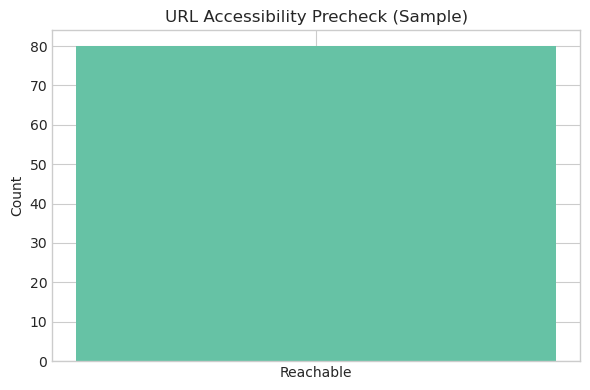

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\03_http_status_distribution.png


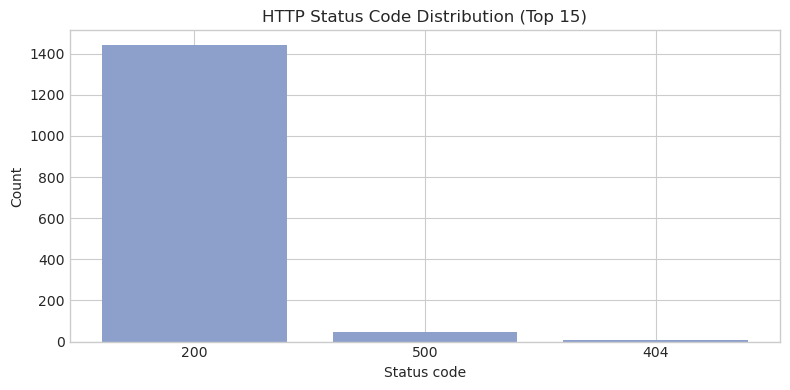

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\04_request_latency_boxplot.png


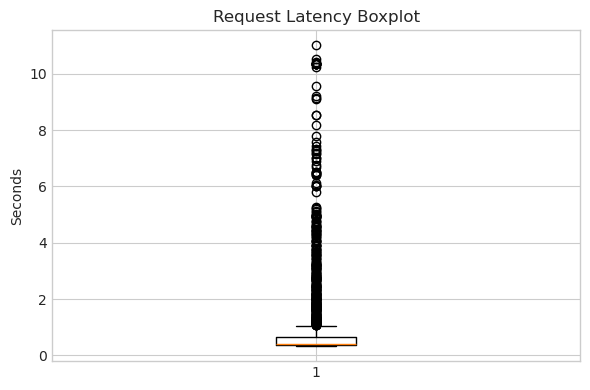

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\05_parsing_success.png


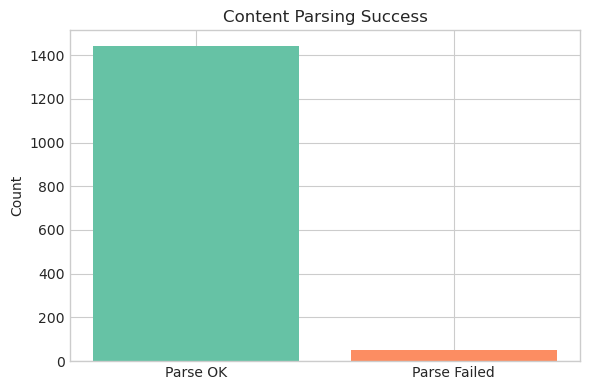

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\06_quality_tier_distribution.png


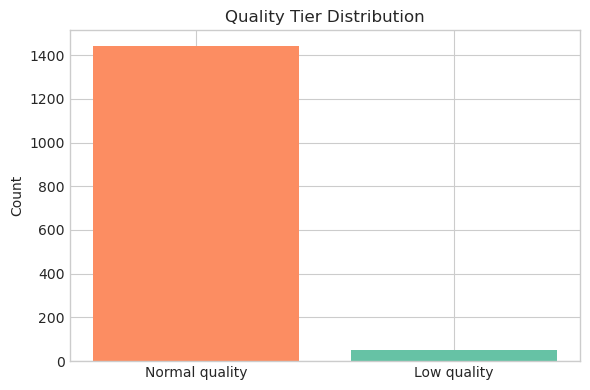

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\07_clean_text_length_distribution.png


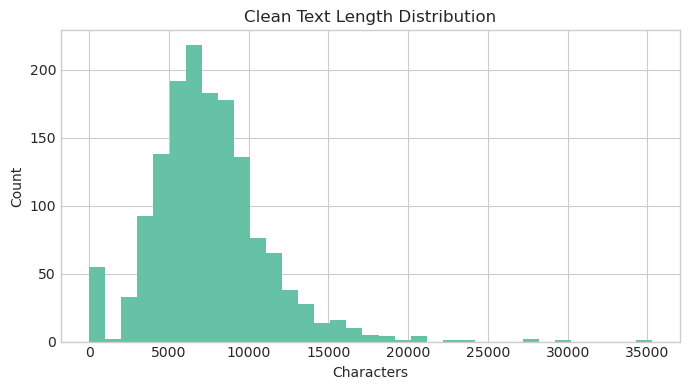

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\08_chunk_count_per_document.png


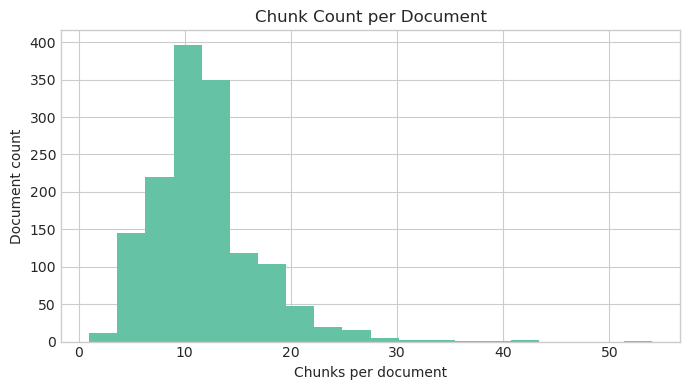

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\09_chunk_length_distribution.png


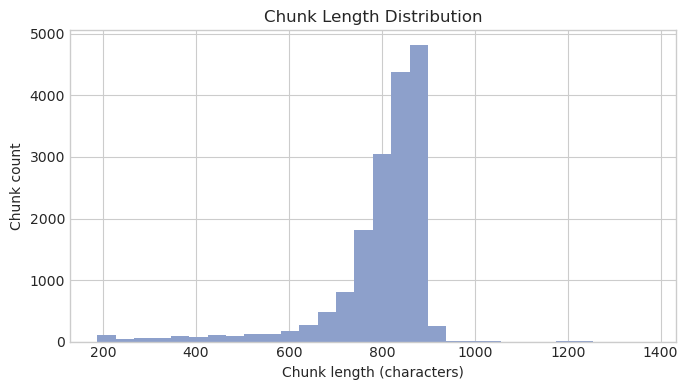

saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\10_incremental_crawl_summary.png


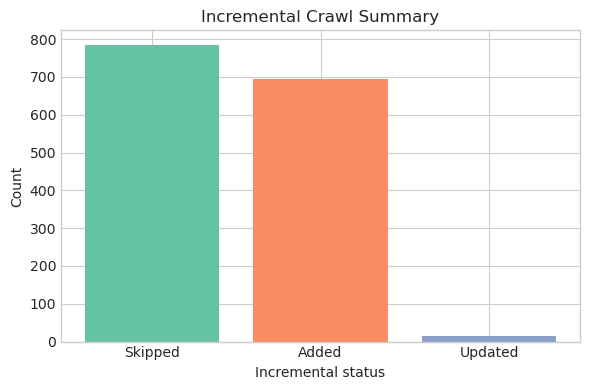

,figure_file
0,01_url_count_before_after.png
1,02_precheck_accessibility.png
2,03_http_status_distribution.png
3,04_request_latency_boxplot.png
4,05_parsing_success.png
5,06_quality_tier_distribution.png
6,07_clean_text_length_distribution.png
7,08_chunk_count_per_document.png
8,09_chunk_length_distribution.png
9,10_incremental_crawl_summary.png


figure index saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figure_index_en.csv


In [15]:
FIG_DIR = REPORT_DIR / 'figures_en'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# English-friendly plotting defaults
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

def savefig(name: str):
    p = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(p, dpi=180, bbox_inches='tight')
    print('saved:', p)

# 1) URL cleaning counts
plt.figure(figsize=(6,4))
plt.bar(['Before cleaning', 'After cleaning'], [before_n, after_n], color=['#8da0cb', '#66c2a5'])
plt.title('URL Count Before vs After Cleaning')
plt.ylabel('Count')
savefig('01_url_count_before_after.png')
plt.show()

# 2) Precheck accessibility
if 'df_pre' in globals() and len(df_pre):
    vc = df_pre['precheck_ok'].value_counts()
    x = ['Reachable' if k else 'Unreachable' for k in vc.index.tolist()]
    plt.figure(figsize=(6,4))
    plt.bar(x, vc.values, color=['#66c2a5', '#fc8d62'])
    plt.title('URL Accessibility Precheck (Sample)')
    plt.ylabel('Count')
    savefig('02_precheck_accessibility.png')
    plt.show()

# 3) HTTP status distribution
if 'df_crawl' in globals() and len(df_crawl):
    status_dist2 = df_crawl['status_code'].fillna(-1).astype(int).value_counts().head(15)
    plt.figure(figsize=(8,4))
    plt.bar(status_dist2.index.astype(str), status_dist2.values, color='#8da0cb')
    plt.title('HTTP Status Code Distribution (Top 15)')
    plt.xlabel('Status code')
    plt.ylabel('Count')
    savefig('03_http_status_distribution.png')
    plt.show()

# 4) Request latency boxplot
if 'df_crawl' in globals() and len(df_crawl):
    vals = df_crawl['elapsed_s'].dropna().values
    if len(vals):
        plt.figure(figsize=(6,4))
        plt.boxplot(vals, vert=True)
        plt.title('Request Latency Boxplot')
        plt.ylabel('Seconds')
        savefig('04_request_latency_boxplot.png')
        plt.show()

# 5) Parsing success
if 'df_parsed' in globals() and len(df_parsed):
    vc = df_parsed['parse_ok'].value_counts()
    x = ['Parse OK' if k else 'Parse Failed' for k in vc.index.tolist()]
    plt.figure(figsize=(6,4))
    plt.bar(x, vc.values, color=['#66c2a5', '#fc8d62'])
    plt.title('Content Parsing Success')
    plt.ylabel('Count')
    savefig('05_parsing_success.png')
    plt.show()

# 6) Quality tier
if 'df_q' in globals() and len(df_q):
    vc = df_q['is_low_quality'].value_counts()
    x = ['Low quality' if k else 'Normal quality' for k in vc.index.tolist()]
    plt.figure(figsize=(6,4))
    plt.bar(x, vc.values, color=['#fc8d62', '#66c2a5'])
    plt.title('Quality Tier Distribution')
    plt.ylabel('Count')
    savefig('06_quality_tier_distribution.png')
    plt.show()

# 7) Clean text length histogram
if 'df_structured' in globals() and len(df_structured):
    plt.figure(figsize=(7,4))
    plt.hist(df_structured['char_count_clean'].fillna(0), bins=35, color='#66c2a5')
    plt.title('Clean Text Length Distribution')
    plt.xlabel('Characters')
    plt.ylabel('Count')
    savefig('07_clean_text_length_distribution.png')
    plt.show()

# 8) Chunk stats for RAG
if 'article_index_df' in globals() and len(article_index_df):
    plt.figure(figsize=(7,4))
    plt.hist(article_index_df['chunk_count'], bins=20, color='#66c2a5')
    plt.title('Chunk Count per Document')
    plt.xlabel('Chunks per document')
    plt.ylabel('Document count')
    savefig('08_chunk_count_per_document.png')
    plt.show()

if 'chunk_df' in globals() and len(chunk_df):
    plt.figure(figsize=(7,4))
    plt.hist(chunk_df['chunk_len'], bins=30, color='#8da0cb')
    plt.title('Chunk Length Distribution')
    plt.xlabel('Chunk length (characters)')
    plt.ylabel('Chunk count')
    savefig('09_chunk_length_distribution.png')
    plt.show()

# 9) Incremental crawl summary
if 'current_manifest' in globals() and len(current_manifest):
    mapping = {
        '新增': 'Added',
        '更新': 'Updated',
        '跳过': 'Skipped',
        'added': 'Added',
        'updated': 'Updated',
        'skipped': 'Skipped',
    }
    status_series = current_manifest['incremental_status'].fillna('Unknown').astype(str).str.strip().replace(mapping)
    vc = status_series.value_counts()
    plt.figure(figsize=(6,4))
    plt.bar(vc.index, vc.values, color=['#66c2a5', '#fc8d62', '#8da0cb'])
    plt.title('Incremental Crawl Summary')
    plt.xlabel('Incremental status')
    plt.ylabel('Count')
    savefig('10_incremental_crawl_summary.png')
    plt.show()

fig_index = pd.DataFrame({'figure_file': [p.name for p in sorted(FIG_DIR.glob('*.png'))]})
display(fig_index)
fig_index.to_csv(REPORT_DIR / 'figure_index_en.csv', index=False, encoding='utf-8-sig')
print('figure index saved:', REPORT_DIR / 'figure_index_en.csv')

In [16]:
ppt_pages = pd.DataFrame([
    ['Slide 1', 'Project Scope & Data Source', 'Goal: build a startup knowledge base from BusinessNewsDaily URLs and prepare data for RAG.', '01_url_count_before_after.png'],
    ['Slide 2', 'URL Cleaning & Validation', 'Show normalization, deduplication, and accessibility precheck strategy.', '02_precheck_accessibility.png'],
    ['Slide 3', 'Crawling Strategy', 'Async crawling with timeout, retry, polite delay, and user-agent rotation.', '03_http_status_distribution.png'],
    ['Slide 4', 'Crawling Performance', 'Explain latency behavior and why current parameters are stable.', '04_request_latency_boxplot.png'],
    ['Slide 5', 'Content Parsing', 'Metadata + main text extraction and parsing success rate.', '05_parsing_success.png'],
    ['Slide 6', 'Quality Control', 'Low-quality detection rules: min length, noise ratio, duplicate paragraph rate.', '06_quality_tier_distribution.png'],
    ['Slide 7', 'Structured Output', 'Final structured schema: url/title/date/author/content/status.', '07_clean_text_length_distribution.png'],
    ['Slide 8', 'RAG Preparation (Doc Store)', 'Each article saved as standalone JSON/TXT for traceability and easy retrieval.', '08_chunk_count_per_document.png'],
    ['Slide 9', 'RAG Preparation (Chunking)', 'Chunk config (size=900, overlap=150) balances context and retrieval granularity.', '09_chunk_length_distribution.png'],
    ['Slide 10', 'Incremental Pipeline', 'Incremental update policy: New/Updated/Skipped URLs for fast re-crawl.', '10_incremental_crawl_summary.png'],
], columns=['slide', 'title', 'speaker_notes', 'figure_file'])

display(ppt_pages)
ppt_pages.to_csv(REPORT_DIR / 'ppt_pages_plan_en.csv', index=False, encoding='utf-8-sig')
print('saved:', REPORT_DIR / 'ppt_pages_plan_en.csv')

,slide,title,speaker_notes,figure_file
0,Slide 1,Project Scope & Data Source,Goal: build a startup knowledge base from BusinessNewsDaily URLs and prepare data for RAG.,01_url_count_before_after.png
1,Slide 2,URL Cleaning & Validation,"Show normalization, deduplication, and accessibility precheck strategy.",02_precheck_accessibility.png
2,Slide 3,Crawling Strategy,"Async crawling with timeout, retry, polite delay, and user-agent rotation.",03_http_status_distribution.png
3,Slide 4,Crawling Performance,Explain latency behavior and why current parameters are stable.,04_request_latency_boxplot.png
4,Slide 5,Content Parsing,Metadata + main text extraction and parsing success rate.,05_parsing_success.png
5,Slide 6,Quality Control,"Low-quality detection rules: min length, noise ratio, duplicate paragraph rate.",06_quality_tier_distribution.png
6,Slide 7,Structured Output,Final structured schema: url/title/date/author/content/status.,07_clean_text_length_distribution.png
7,Slide 8,RAG Preparation (Doc Store),Each article saved as standalone JSON/TXT for traceability and easy retrieval.,08_chunk_count_per_document.png
8,Slide 9,RAG Preparation (Chunking),"Chunk config (size=900, overlap=150) balances context and retrieval granularity.",09_chunk_length_distribution.png
9,Slide 10,Incremental Pipeline,Incremental update policy: New/Updated/Skipped URLs for fast re-crawl.,10_incremental_crawl_summary.png


saved: e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\ppt_pages_plan_en.csv


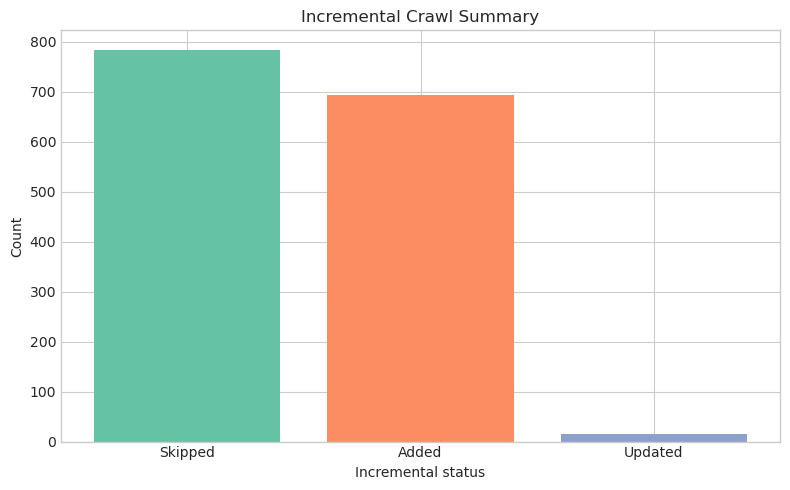

saved (english labels): e:\研究生资料\7102\project\data\dataset_businessnewsdaily\reports\figures_en\10_incremental_crawl_summary.png


In [17]:
# Optional: regenerate figure 10 only (English labels)
fig_dir_en = REPORT_DIR / 'figures_en'
fig_dir_en.mkdir(parents=True, exist_ok=True)

if 'current_manifest' in globals() and len(current_manifest) > 0:
    mapping = {
        '新增': 'Added',
        '更新': 'Updated',
        '跳过': 'Skipped',
        'added': 'Added',
        'updated': 'Updated',
        'skipped': 'Skipped',
    }
    status_series = current_manifest['incremental_status'].fillna('Unknown').astype(str).str.strip().replace(mapping)
    status_counts = status_series.value_counts()

    plt.figure(figsize=(8, 5))
    plt.bar(status_counts.index.tolist(), status_counts.values.tolist(), color=['#66c2a5', '#fc8d62', '#8da0cb'][:len(status_counts)])
    plt.title('Incremental Crawl Summary')
    plt.xlabel('Incremental status')
    plt.ylabel('Count')
    plt.tight_layout()

    p10 = fig_dir_en / '10_incremental_crawl_summary.png'
    plt.savefig(p10, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved (english labels):', p10)
else:
    print('current_manifest is missing or empty; run the incremental section first.')